In [1]:
###!/usr/bin/env python
################################################
# New style 
# ###############################################
import sys

rootdir_ = '../'
if ( rootdir_ not in sys.path ):
    sys.path.append(rootdir_)
    print( f" a path to {rootdir_} added in {__name__} ")


from Utils import GridUtils as GrU
from Utils import MakePressures as MkP
from Utils import utils as uti
from Utils import MyConstants as Co
from Utils import time_utils as tuti
from Utils import numerical_utils as nuti

import analysis_utils as auti
import file_utils as futi
import event_utils as euti
import event_io as eio


#from PyRegridding.Utils import MakePressures as MkP
#from Drivers import RegridField as RgF
import RegridField as RgF

# The usual
from datetime import date
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# for smoothing , nonlienar colors ...
from scipy.ndimage import uniform_filter
from scipy.ndimage import gaussian_filter
import matplotlib.colors as mcolors

# Some other useful packages 
import copy
import time
import cftime
import yaml
import numbers
import pickle

# Some other useful packages 
import importlib
from pathlib import Path


importlib.reload( auti )
importlib.reload( futi )
importlib.reload( euti )
importlib.reload( eio )

Rdair=Co.Rdair()


 a path to ../ added in __main__ 
 Utils.MyConstants in /glade/work/juliob/HiRes_ana_dev/Drivers/Utils 
Using Flexible parallel/serial VertRegrid 
 Utils.MyConstants in /glade/work/juliob/HiRes_ana_dev/Drivers/Utils 
 a path to /glade/work/juliob added in Utils.numerical_utils 


In [2]:
# This allow both dict.key and dict['key'] syntax
class AttrDict(dict):
    def __getattr__(self, key):
        try:
            return self[key]
        except KeyError:
            raise AttributeError(f"'AttrDict' object has no attribute '{key}'")

    def __setattr__(self, key, value):
        self[key] = value

    def __delattr__(self, key):
        try:
            del self[key]
        except KeyError:
            raise AttributeError(f"'AttrDict' object has no attribute '{key}'")



In [3]:
%%time
importlib.reload( futi )
importlib.reload( nuti )
nsteps=None
start_date=None
super_lat_range = [-90.,90.]  #[-85,-30]
case, process_ncdata  = 'cam77_dyamond1_prod1'    , False

A = futi.read_case( case=case, nsteps=nsteps, start_date=start_date , super_lat_range=super_lat_range ) # , nsteps = 31*8 )

time, zlev, lat, lon = A.time, A.zlev, A.lat, A.lon

GWP_vars_file=f"{case}_src_fit_vars_4.nc"

GWP = xr.open_dataset( GWP_vars_file )

  nsteps=247 
/glade/derecho/scratch/juliob/archive/cam77_dyamond1_prod1/atm/hist/DynVars_dyamond_fv1x1.2016-08-01-10800.nc /glade/derecho/scratch/juliob/archive/cam77_dyamond1_prod1/atm/hist/DynVars_dyamond_fv1x1.2016-08-31-75600.nc
 Dataset opened  , dtype of U,V float32 float32 
 Dataset opened  trimmed. -89.76 to  89.76 
Read subsetted X w open_mfdata_set  160.8591 seconds
extracted upwp,...U,V,T etc  101.9845 seconds
Vorticity calc  4.7676 seconds
rho geopht pint ... calc  35.2738 seconds
rho calc ... epwp  8.7903 seconds
(247, 58, 192, 288)
(247, 58, 192, 288)
(247, 58, 192, 288)
(247, 58, 192, 288)
tilting calc  10.3968 seconds
this is Sphere_grad_vec in numerical_utils in HiRes_ana
dlat has been adjusted to account for FUCKED UP CRAPPY fv1x1 SCRIP FILE IN CESMDATA INPUTs!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!! 
frontogenesis calc  24.4975 seconds
stability calc  3.6511 seconds
CPU times: user 1min 13s, sys: 1min 16s, total: 2min 30s
Wall time: 6min 25s


In [4]:
GWP

<xarray.Dataset> Size: 1GB
Dimensions:     (time: 247, lat: 192, lon: 288, lev: 58)
Coordinates:
  * time        (time) datetime64[ns] 2kB 2016-08-01 ... 2016-08-31T18:00:00
  * lat         (lat) float64 2kB -89.76 -89.06 -88.12 ... 88.12 89.06 89.76
  * lon         (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
  * lev         (lev) float64 464B 4.112e+04 3.687e+04 3.323e+04 ... 106.2 35.0
Data variables: (12/14)
    epwp_zl     (time, lat, lon) float32 55MB ...
    tilt_zs_zl  (time, lat, lon) float64 109MB ...
    tilt_zg_zs  (time, lat, lon) float64 109MB ...
    tilt_zs     (time, lat, lon) float64 109MB ...
    tilt_zl     (time, lat, lon) float64 109MB ...
    zeta_zs     (time, lat, lon) float64 109MB ...
    ...          ...
    v_zs        (time, lat, lon) float32 55MB ...
    u_zl        (time, lat, lon) float32 55MB ...
    v_zl        (time, lat, lon) float32 55MB ...
    k_launch    (time, lat, lon) int64 109MB ...
    k_steer     (time, lat, lon) int64 109MB ...
    precl       (time, lat, lon) float32 55MB ...

In [5]:
%%time

case='xympas-DynZlZs-tilt-x02'
dates='2016-08-*'
foo=f"/glade/derecho/scratch/juliob/archive/GW_UnitTest/{case}/{case}.h.{dates}.nc"
Xgw=xr.open_mfdataset( foo , data_vars='different', coords='different', compat='no_conflicts' )


ny = Xgw.sizes["ny"]
nx = Xgw.sizes["nx"]

j = np.arange(ny).repeat(nx)
i = np.tile(np.arange(nx), ny)

X2 = (
    Xgw.assign_coords(_j=("ncol", j), _i=("ncol", i))     # mapping ncol -> (j,i)
     .set_index(ncol=("_j", "_i"))
     .unstack("ncol")
     .rename({"_j": "ny", "_i": "nx"})
     .assign_coords(ny=Xgw["lat_R"], nx=Xgw["lon_R"])        # put real coords on axes
)


X2['lat']=Xgw['lat_R']
X2['lon']=Xgw['lon_R']
Xgw=X2

CPU times: user 30.5 s, sys: 5.94 s, total: 36.5 s
Wall time: 2min 56s


In [6]:
%%time
xpwp_src_1_2  = Xgw.XPWP_SRC_1.values
xpwp_src_3_2  = Xgw.XPWP_SRC_3.values
xpwp_src_3_2[:,-1,:]=0.


CPU times: user 4.84 s, sys: 780 ms, total: 5.62 s
Wall time: 25.6 s


In [7]:
%%time
lat1,lon1=Xgw.lat.values, Xgw.lon.values

k_steer_1  = Xgw.K_STEER_MOVMTN.values
k_launch_1 = Xgw.K_LAUNCH_MOVMTN.values
p_steer_1  = Xgw.P_STEER_MOVMTN.values
p_launch_1 = Xgw.P_LAUNCH_MOVMTN.values
pmid_mm_1 = Xgw.PMID_MOVMTN.values
pmid_1    = Xgw.PMID.values

xpwp_src_1_1  = Xgw.XPWP_SRC_1.values
xpwp_src_3_1  = Xgw.XPWP_SRC_3.values

tau_mm_1 = Xgw.TAU_MOVMTN.values
sgh=Xgw.SGH.values

xpwp_src_3_1[:,-1,:]=0.

z_steer_1 = -7_000. * np.log( p_steer_1 / 100_000. )
z_launch_1 = -7_000. * np.log( p_launch_1 / 100_000. )

usteer_1  = Xgw.USTEER_MOVMTN.values
ulaunch_1 = Xgw.ULAUNCH_MOVMTN.values

vsteer_1  = Xgw.VSTEER_MOVMTN.values
vlaunch_1 = Xgw.VLAUNCH_MOVMTN.values

uwavef_1 = Xgw.UWAVEF_MOVMTN.values
vwavef_1 = Xgw.VWAVEF_MOVMTN.values


CPU times: user 42.1 s, sys: 28.5 s, total: 1min 10s
Wall time: 4min 2s


In [8]:
k_steer=GWP.k_steer.values

tilt_zs_zl = GWP.tilt_zs_zl.values
tilt_zg_zs = GWP.tilt_zg_zs.values
tilt_zl = GWP.tilt_zl.values
tilt_zs = GWP.tilt_zs.values
epwp_zl = GWP.epwp_zl.values
precl = GWP.precl.values
u_zs = GWP.u_zs.values
v_zs = GWP.v_zs.values

In [9]:
Topo=xr.open_dataset( A.topo_file )
sgh=Topo.SGH.values

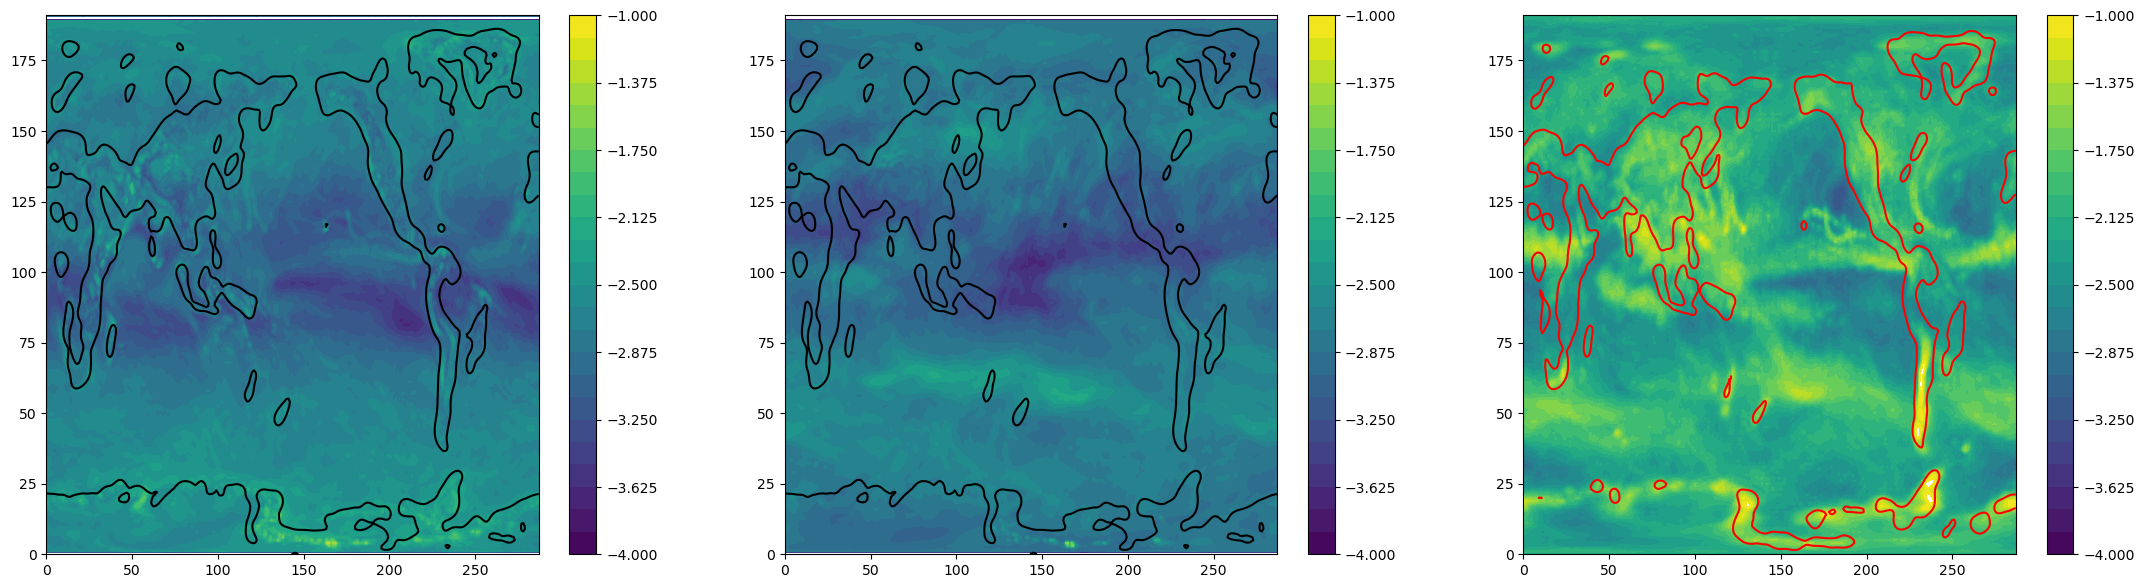

In [10]:
from scipy.ndimage import gaussian_filter

#smoothed = gaussian_filter(field, sigma=2)  # sigma in grid points

logmflv = np.linspace( -6,-1, num=25 )
logmflv = np.linspace( -4,-1, num=25 )
sgh_smooth = gaussian_filter( sgh, sigma=2) 
mxd_smooth = gaussian_filter( A.mxdis, sigma=2) 

t=100
t0,t1=0,247 #100,100
#xpwp_src_3_1.shape
fig,axs=plt.subplots( 1,3, figsize=(3*9,7) ) 
ax=axs[0]
co=ax.contourf(  np.log10( xpwp_src_1_2[t0:t1+1,:,:].mean( axis=0)+1e-6) , levels=logmflv )
li=ax.contour( sgh_smooth , levels=[100,1000] , colors='black' )
#lu=ax.contour( mxd_smooth , levels=[100,1000] , colors='red' )
plt.colorbar( co )
ax=axs[1]
co=ax.contourf(  np.log10( xpwp_src_3_2[t0:t1+1,:,:].mean( axis=0)+1e-6) , levels=logmflv )
li=ax.contour( sgh_smooth , levels=[100,1000] , colors='black' )
#co=ax.contourf(   tilt_zs_zl[t0:t1+1,:,:].mean( axis=0) )
plt.colorbar( co )
ax=axs[2]
co=ax.contourf(   np.log10( epwp_zl[t0:t1+1,:,:].mean( axis=0)  ) , levels=logmflv )
#li=ax.contour( sgh_smooth , levels=[100,1000] , colors='black' )
lu=ax.contour( mxd_smooth , levels=[200, 2000] , colors='red' )
plt.colorbar( co )


In [11]:
lat=GWP.lat.values
print( ny, nx )
latyx=np.tile( lat[:,None], (1,nx) )
print(latyx.shape)


mask=( mxd_smooth<200.) & (latyx >=-60.) & (latyx<=-40)
mask=( mxd_smooth<200.) & (latyx >=-80.) & (latyx<=-20)

maskN=( mxd_smooth<200.) & (latyx <=80.) & (latyx>=0)
maskG=( mxd_smooth<200.) & (latyx <=90.) & (latyx>=-90)

mask=maskG

192 288
(192, 288)


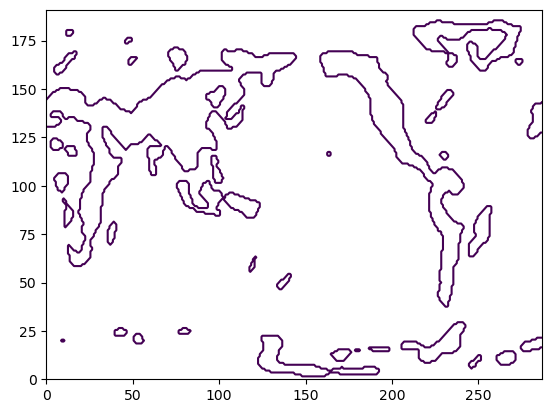

In [12]:
plt.contour( maskG )

In [13]:

"""
case, process_ncdata  = 'cam77_dyamond1_prod1'    , False
GWP_vars_file=f"{case}_src_fit_vars_4.nc"
print( GWP_vars_file )
GWP = xr.open_dataset( GWP_vars_file )
"""

tilt_zg_zs=GWP.tilt_zg_zs.values
tilt_zs_zl=GWP.tilt_zs_zl.values
tilt_zs=GWP.tilt_zs.values
tilt_zl=GWP.tilt_zl.values
zeta_zs=GWP.zeta_zs.values
zeta_zl=GWP.zeta_zl.values


In [14]:
import numpy as np
import distro_fitting as DF
importlib.reload(DF)

P = precl
D = tilt_zs   #_zl
Y = epwp_zl

mask=maskG

D, P, Y = (gaussian_filter(Q, sigma=(0,2,2), mode=('reflect','reflect','wrap'))
           for Q in (D, P, Y))

#D = DF.ema(D, 0.3)
#P = DF.ema(P, 0.3)

# --- keep the (nt, ncol) shape so time stays an axis -----------------------
D2, P2, Y2 = (Q[:, mask] for Q in (D, P, Y))     # each (nt, ncol)
nt, ncol = Y2.shape
print(f"nt={nt}  ncol={ncol}  total samples={nt*ncol:,}")

# --- time-block masks, defined on the time axis ----------------------------
tt = np.arange(nt)
t_train = (tt >= 48) & (tt < 248)                # times 48 .. nt-1
t_test  = (tt >=  0) & (tt <  28)                # times  0 .. 27
print(f"train times: {t_train.sum()}   test times: {t_test.sum()}   "
      f"gap: {48-28} steps = {(48-28)*3} hours")

# --- flatten each subset separately ----------------------------------------
dd_tr, pp_tr, yy_tr = (Q[t_train].ravel() for Q in (D2, P2, Y2))
dd_te, pp_te, yy_te = (Q[t_test ].ravel() for Q in (D2, P2, Y2))

print(f"train samples: {yy_tr.size:,}   test samples: {yy_te.size:,}")

new=True
if new==True:
    dd, pp, yy = dd_tr, pp_tr, yy_tr
else:
    # --- keep the full-sample arrays too, so existing cells still run ----------
    dd, pp, yy = (Q.ravel() for Q in (D2, P2, Y2))
    tidx = np.repeat(tt, ncol)                       # time index per sample

nt=247  ncol=46548  total samples=11,497,356
train times: 199   test times: 28   gap: 20 steps = 60 hours
train samples: 9,263,052   test samples: 1,303,344


In [15]:
p_dry=0.9e-8
med, cnt, d_edges, p_edges = DF.bin_shape_1d(dd, pp, yy, n_d=16, n_p=12, min_count=200,y_floor=None, p_dry=p_dry )
dc = np.sqrt(d_edges[:-1] * d_edges[1:])
pc = np.sqrt(np.maximum(p_edges[:-1], p_dry) * p_edges[1:])

9263052 points (4360246 dry)


[None, None, Text(0.5, 0, 'precl'), Text(0, 0.5, 'median epwp')]

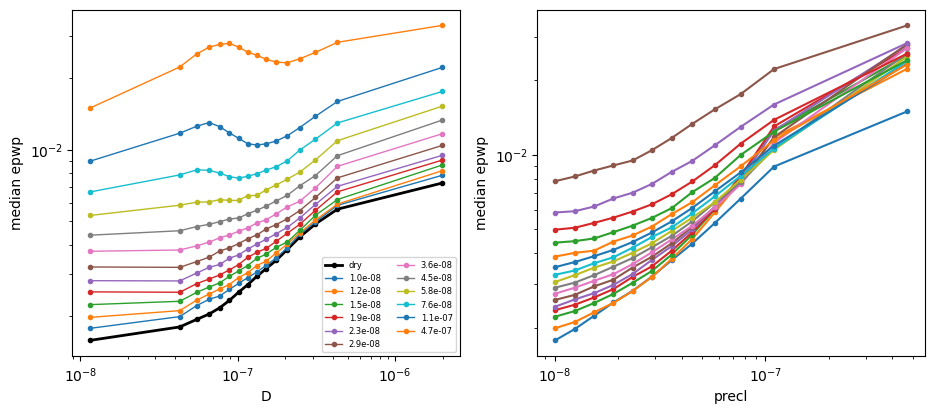

In [16]:
dc = np.sqrt(d_edges[:-1] * d_edges[1:])
pc = np.sqrt(np.maximum(p_edges[:-1], p_dry) * p_edges[1:])

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
for j in range(med.shape[1]):
    ax[0].plot(dc, med[:, j], marker='o', ms=3, lw=2 if j == 0 else 1,
               color='k' if j == 0 else None,
               label='dry' if j == 0 else f'{pc[j]:.1e}')
ax[0].set(xscale='log', yscale='log', xlabel='D', ylabel='median epwp')
ax[0].legend(fontsize=6, ncol=2)
for i in range(med.shape[0]):
    ax[1].plot(pc[1:], med[i, 1:], marker='o', ms=3)
ax[1].set(xscale='log', yscale='log', xlabel='precl', ylabel='median epwp')

In [17]:
sp=DF.cell_spread(dd, pp, yy, d_edges, p_edges, min_count=200, p_dry=p_dry)

cells used:          208 of 208
within-cell  var:    0.6843  (log units)
between-cell var:    0.4300
explained fraction:  0.386
ceiling on log-r:    0.621
median 16–84 spread: 4.80x


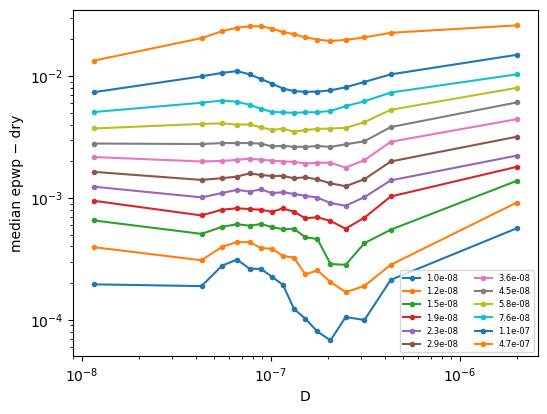

In [18]:
diff = med[:, 1:] - med[:, [0]]        # linear space, not log

fig, ax = plt.subplots(figsize=(6, 4.5))
for j in range(diff.shape[1]):
    ax.plot(dc, diff[:, j], marker='o', ms=3, label=f'{pc[j+1]:.1e}')
ax.set(xscale='log', yscale='log', xlabel='D', ylabel='median epwp − dry')
ax.legend(fontsize=6, ncol=2)

NNLS grid: 45375 nodes on 100000 points
NNLS grid best fit:
  y0  = 0
  A   = 0.0802403
  a   = 1.5
  D0  = 3e-08
  B   = 0.00267287
  b   = 1.2
  c   = 0.1
  residual = 3.3407
Log-space polish:
  y0  = 0   (NNLS: 0)  [fixed]
  A   = 0.408697   (NNLS: 0.0802403)
  a   = 1.5182   (NNLS: 1.5)
  D0  = 3.37081e-09   (NNLS: 3e-08)
  B   = 0.0018192   (NNLS: 0.00267287)
  b   = 1.27887   (NNLS: 1.2)
  c   = 0.0383258   (NNLS: 0.1)
  cost = 2.35847e+06,  success = True
--- SH fit ---
  r_full (log)     = 0.6260
  pred/obs median  = 1.001   16-84%: 0.453-2.210
  implied sigma    = 0.792  (log units, for stochastic)
  r_form (surface) = 0.9653  [count-weighted]
residual map: 208 of 208 cells
  spread (std over cells)      = 0.0823
  max |median residual|        = 0.2531
  count-weighted mean |res|    = 0.0536
  fraction of points |res|>0.3 = 0.000
  Spearman vs D bin = +0.159
  Spearman vs P bin = -0.158


<Axes: xlabel='log10 precl', ylabel='log10 D'>

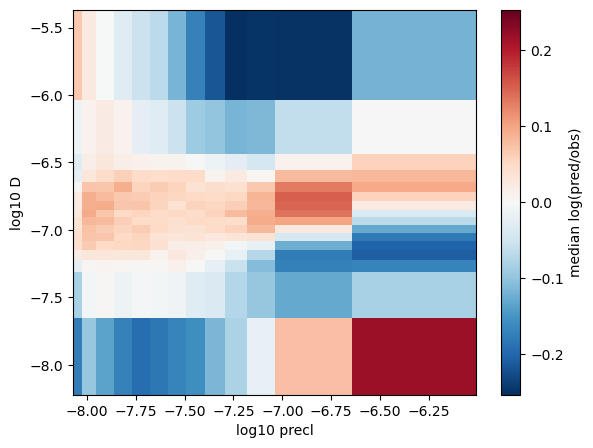

In [19]:
import importlib, source_fit_refvals as SF
importlib.reload(SF)

use_y0=False
g7 = SF.fit_nnls_grid(dd, pp, yy, use_y0=use_y0)
par7_grid=g7['params']
par7, out = SF.fit_log_polish(dd, pp, yy, par7_grid , use_y0=use_y0)
SF.score(dd, pp, yy, par7, med=med, dc=dc, pc=pc, cnt=cnt, label='SH fit')
res, rcnt = SF.residual_map(dd, pp, yy, par7, d_edges, p_edges)
SF.plot_residual_map(res, dc, pc)

In [20]:
print( " oh poopypants " )

"""
# - Skip this
import importlib, source_fit as SF
importlib.reload(SF)

g6 = SF.fit_nnls_grid(dd, pp, yy, use_y0=False, c_grid=[0.0] )
par, _ = SF.fit_log_polish(dd, pp, yy, g['params'] , use_y0=False, fix_c=True )
SF.score(dd, pp, yy, par, med=med, dc=dc, pc=pc, cnt=cnt, label='SH fit')
res, rcnt = SF.residual_map(dd, pp, yy, par, d_edges, p_edges)
SF.plot_residual_map(res, dc, pc)
"""

 oh poopypants 


"\n# - Skip this\nimport importlib, source_fit as SF\nimportlib.reload(SF)\n\ng6 = SF.fit_nnls_grid(dd, pp, yy, use_y0=False, c_grid=[0.0] )\npar, _ = SF.fit_log_polish(dd, pp, yy, g['params'] , use_y0=False, fix_c=True )\nSF.score(dd, pp, yy, par, med=med, dc=dc, pc=pc, cnt=cnt, label='SH fit')\nres, rcnt = SF.residual_map(dd, pp, yy, par, d_edges, p_edges)\nSF.plot_residual_map(res, dc, pc)\n"

NNLS grid: 4125 nodes on 100000 points
NNLS grid best fit:
  y0  = 0
  A   = 0.0798292
  a   = 1.6
  D0  = 3e-08
  B   = 0.00252784
  b   = 1.2
  c   = 0
  residual = 3.3409
Log-space polish:
  y0  = 0   (NNLS: 0)  [fixed]
  A   = 0.408697   (NNLS: 0.0798292)
  a   = 1.52598   (NNLS: 1.6)
  D0  = 3.40441e-09   (NNLS: 3e-08)
  B   = 0.00172452   (NNLS: 0.00252784)
  b   = 1.28493   (NNLS: 1.2)
  c   = 0   (NNLS: 0)  [fixed]
  cost = 2.35887e+06,  success = True
--- SH fit ---
  r_full (log)     = 0.6260
  pred/obs median  = 1.001   16-84%: 0.453-2.210
  implied sigma    = 0.793  (log units, for stochastic)
  r_form (surface) = 0.9652  [count-weighted]
residual map: 208 of 208 cells
  spread (std over cells)      = 0.0817
  max |median residual|        = 0.2865
  count-weighted mean |res|    = 0.0532
  fraction of points |res|>0.3 = 0.000
  Spearman vs D bin = +0.115
  Spearman vs P bin = -0.221


<Axes: xlabel='log10 precl', ylabel='log10 D'>

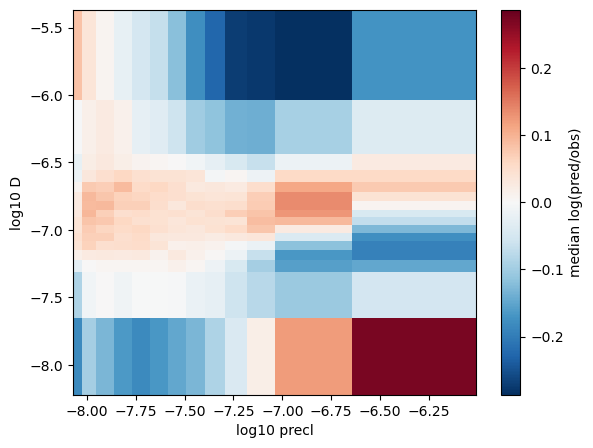

In [21]:
import importlib, source_fit_refvals as SF
importlib.reload(SF)

use_y0=False
g6 = SF.fit_nnls_grid(dd, pp, yy, use_y0=use_y0, c_grid=[0.0] )
par6_grid = g6['params']
par6, _ = SF.fit_log_polish(dd, pp, yy, par6_grid , use_y0=use_y0, fix_c=True )
SF.score(dd, pp, yy, par6, med=med, dc=dc, pc=pc, cnt=cnt, label='SH fit')
res, rcnt = SF.residual_map(dd, pp, yy, par6, d_edges, p_edges)
SF.plot_residual_map(res, dc, pc)

In [22]:
print((GWP.k_launch.values < 0).sum(), (GWP.k_steer.values < 0).sum())

0 0


In [23]:
#par6 = g6['params']

s6_score1 = SF.score(dd, pp, yy, par6, med=med, dc=dc, pc=pc, cnt=cnt, label='6-param training fit. Score 1')
s6_score2 = SF.score(dd, pp, yy, par6, label='6-param training fit. Score 2')
s7_score1 = SF.score(dd, pp, yy, par7, med=med, dc=dc, pc=pc, cnt=cnt, label='7-param training fit. Score 1')
s7_score2 = SF.score(dd, pp, yy, par7, label='7-param training fit. Score 2')


--- 6-param training fit. Score 1 ---
  r_full (log)     = 0.6260
  pred/obs median  = 1.001   16-84%: 0.453-2.210
  implied sigma    = 0.793  (log units, for stochastic)
  r_form (surface) = 0.9652  [count-weighted]
--- 6-param training fit. Score 2 ---
  r_full (log)     = 0.6260
  pred/obs median  = 1.001   16-84%: 0.453-2.210
  implied sigma    = 0.793  (log units, for stochastic)
--- 7-param training fit. Score 1 ---
  r_full (log)     = 0.6260
  pred/obs median  = 1.001   16-84%: 0.453-2.210
  implied sigma    = 0.792  (log units, for stochastic)
  r_form (surface) = 0.9653  [count-weighted]
--- 7-param training fit. Score 2 ---
  r_full (log)     = 0.6260
  pred/obs median  = 1.001   16-84%: 0.453-2.210
  implied sigma    = 0.792  (log units, for stochastic)


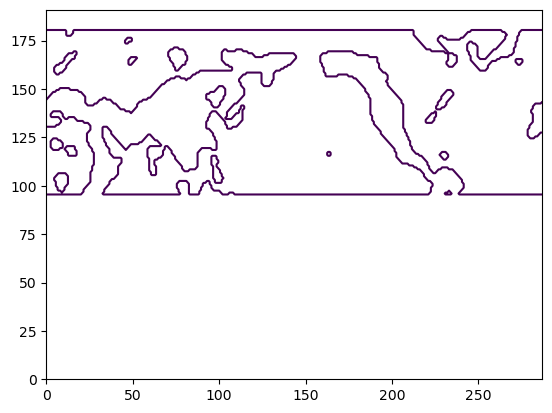

In [24]:
#NH transfer

plt.contour( maskN )

P=precl
D=tilt_zs
Y=epwp_zl
D, P, Y = ( gaussian_filter( Q ,sigma=(0,2,2) ,mode=('reflect','reflect','wrap'))    for Q in (D, P, Y))

ddN , ppN , yyN = (  Q[:, maskN].ravel()   for Q in (D,P, Y) )



In [25]:
#par6 = g6['params']

s6_score_SH = SF.score(dd, pp, yy, par6, label='6-param training score')
s6_score_NH = SF.score(dd_te, pp_te, yy_te, par6, label='6-param test score')


s7_score_SH = SF.score(dd, pp, yy, par7, label='7-param training score ')
s7_score_NH = SF.score(dd_te, pp_te, yy_te, par7, label='7-param test score ')


--- 6-param training score ---
  r_full (log)     = 0.6260
  pred/obs median  = 1.001   16-84%: 0.453-2.210
  implied sigma    = 0.793  (log units, for stochastic)
--- 6-param test score ---
  r_full (log)     = 0.5797
  pred/obs median  = 0.934   16-84%: 0.401-2.120
  implied sigma    = 0.833  (log units, for stochastic)
--- 7-param training score  ---
  r_full (log)     = 0.6260
  pred/obs median  = 1.001   16-84%: 0.453-2.210
  implied sigma    = 0.792  (log units, for stochastic)
--- 7-param test score  ---
  r_full (log)     = 0.5793
  pred/obs median  = 0.934   16-84%: 0.401-2.121
  implied sigma    = 0.833  (log units, for stochastic)


In [26]:
print( par6 )

{'A': np.float64(0.40869677065223653), 'a': np.float64(1.52597876834913), 'D0': np.float64(3.404408823736498e-09), 'B': np.float64(0.0017245194619367127), 'b': np.float64(1.2849326036536837), 'c': np.float64(0.0), 'y0': 0.0}


{'y0': np.float64(0.0), 'A': np.float64(0.08024033859682783), 'a': np.float64(1.5), 'D0': np.float64(3.000000000000001e-08), 'B': np.float64(0.0026728675895929194), 'b': np.float64(1.2), 'c': np.float64(0.1)}
0.0
0.6173694551739684


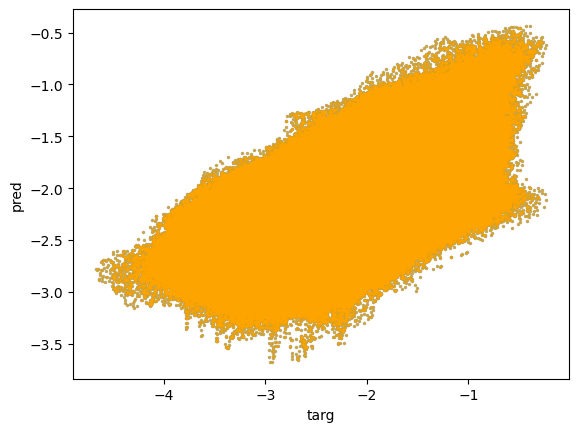

In [27]:
print(g7['params'])
pa=AttrDict(g7['params'])
print( pa.y0 )


epwp_pred = SF.source_model(dd, pp, pa.y0, pa.A, pa.a, pa.D0, pa.B, pa.b, c=pa.c)
epwp_pred_2 = SF.source_model(dd, pp, 0. , pa.A, pa.a, pa.D0, pa.B, pa.b, c=pa.c)

fig, ax = plt.subplots()

ax.scatter(np.log10(yy+1.e-12) ,
           np.log10(epwp_pred+1.e-12) ,
           s=2, alpha=0.5)
ax.scatter(np.log10(yy+1.e-12) ,
           np.log10(epwp_pred_2+1.e-12) ,
           s=2, alpha=0.5,c='orange')

ax.set_xlabel('targ')
ax.set_ylabel('pred')



r_transfer = np.corrcoef(np.log(epwp_pred), np.log(yy))[0, 1]

print( r_transfer)

In [28]:
import numpy as np
import distro_fitting as DF
importlib.reload(DF)

P = precl
D_l = tilt_zl   #_zl
D_g = tilt_zg_zs #_zl
UU_s = u_zs
VV_s = v_zs

mask=maskG

P, D_l, D_g, UU_s, VV_s  = (gaussian_filter(Q, sigma=(0,2,2), mode=('reflect','reflect','wrap'))
                           for Q in ( P, D_l, D_g, UU_s, VV_s ))

#D = DF.ema(D, 0.3)
#P = DF.ema(P, 0.3)

# --- keep the (nt, ncol) shape so time stays an axis -----------------------
P2, D_l2, D_g2, UU_s2, VV_s2  = (Q[:, mask] for Q in ( P, D_l, D_g, UU_s, VV_s  ))     # each (nt, ncol)
nt, ncol = P2.shape
print(f"nt={nt}  ncol={ncol}  total samples={nt*ncol:,}")

# --- time-block masks, defined on the time axis ----------------------------
tt = np.arange(nt)
t_train = (tt >= 48) & (tt < 248)                # times 48 .. nt-1
t_test  = (tt >=  0) & (tt <  28)                # times  0 .. 27
print(f"train times: {t_train.sum()}   test times: {t_test.sum()}   "
      f"gap: {48-28} steps = {(48-28)*3} hours")

# --- flatten each subset separately ----------------------------------------
P_tr, D_l_tr, D_g_tr, UU_s_tr, VV_s_tr = (Q[t_train].ravel() for Q in ( P2, D_l2, D_g2, UU_s2, VV_s2  ))



##dd_te, pp_te, yy_te = (Q[t_test ].ravel() for Q in (D2, P2, Y2))

##print(f"train samples: {yy_tr.size:,}   test samples: {yy_te.size:,}")


nt=247  ncol=46548  total samples=11,497,356
train times: 199   test times: 28   gap: 20 steps = 60 hours


In [29]:
print( yy.shape )
print( D_g_tr.shape )
print( P_tr.shape )


(9263052,)
(9263052,)
(9263052,)


In [41]:
import gw_srcs as GWs
importlib.reload( GWs )
epwp_pred_3 = GWs.pysr_cx17(tilt_zg_zs=D_g_tr, tilt_zl=D_l_tr , u_zs=UU_s_tr, v_zs=VV_s_tr, precl=P_tr)
epwp_pred_4 = GWs.pysr_cx17(tilt_zg_zs=D_g_tr, tilt_zl=D_l_tr , u_zs=UU_s_tr, v_zs=VV_s_tr, precl=P_tr, A=4.0 ,B=0.25, C=0.5)
epwp_pred_5 = GWs.pysr_cx17(tilt_zg_zs=D_g_tr, tilt_zl=D_l_tr , u_zs=UU_s_tr, v_zs=VV_s_tr, precl=P_tr, A=1.0 ,B=0., C=0.)

epwp_pred_3_tyx = GWs.pysr_cx17(tilt_zg_zs=tilt_zg_zs , tilt_zl=tilt_zl , u_zs=u_zs , v_zs=v_zs , precl=precl)
epwp_pred_4_tyx = GWs.pysr_cx17(tilt_zg_zs=tilt_zg_zs , tilt_zl=tilt_zl , u_zs=u_zs , v_zs=v_zs , precl=precl , A=4.0 ,B=0.25, C=0.5)
epwp_pred_5_tyx = GWs.pysr_cx17(tilt_zg_zs=tilt_zg_zs , tilt_zl=tilt_zl , u_zs=u_zs , v_zs=v_zs , precl=precl , A=1.0 ,B=0., C=0.)
epwp_pred_6_tyx = GWs.pysr_cx17(tilt_zg_zs=tilt_zg_zs , tilt_zl=tilt_zl , u_zs=u_zs , v_zs=v_zs , precl=precl , A=0.0 ,B=1., C=0.)
epwp_pred_7_tyx = GWs.pysr_cx17(tilt_zg_zs=tilt_zg_zs , tilt_zl=tilt_zl , u_zs=u_zs , v_zs=v_zs , precl=precl , A=0.0 ,B=0., C=1.)



In [43]:
epwp_pred_3_tyx[:, ~mask] = 0.  #np.nan
epwp_pred_4_tyx[:, ~mask] = 0.  #np.nan
epwp_pred_5_tyx[:, ~mask] = 0.  #np.nan
epwp_pred_6_tyx[:, ~mask] = 0.  #np.nan
epwp_pred_7_tyx[:, ~mask] = 0.  #np.nan
epwp_zl_mask=epwp_zl
epwp_zl_mask[:,~mask]=0.

/glade/derecho/scratch/juliob/tmp/ipykernel_125337/769216808.py:49: RuntimeWarning: divide by zero encountered in log10
  co=ax.contourf(   np.log10( epwp_zl_mask[t0:t1+1,:,:].mean( axis=0)  ) , levels=logmflv )


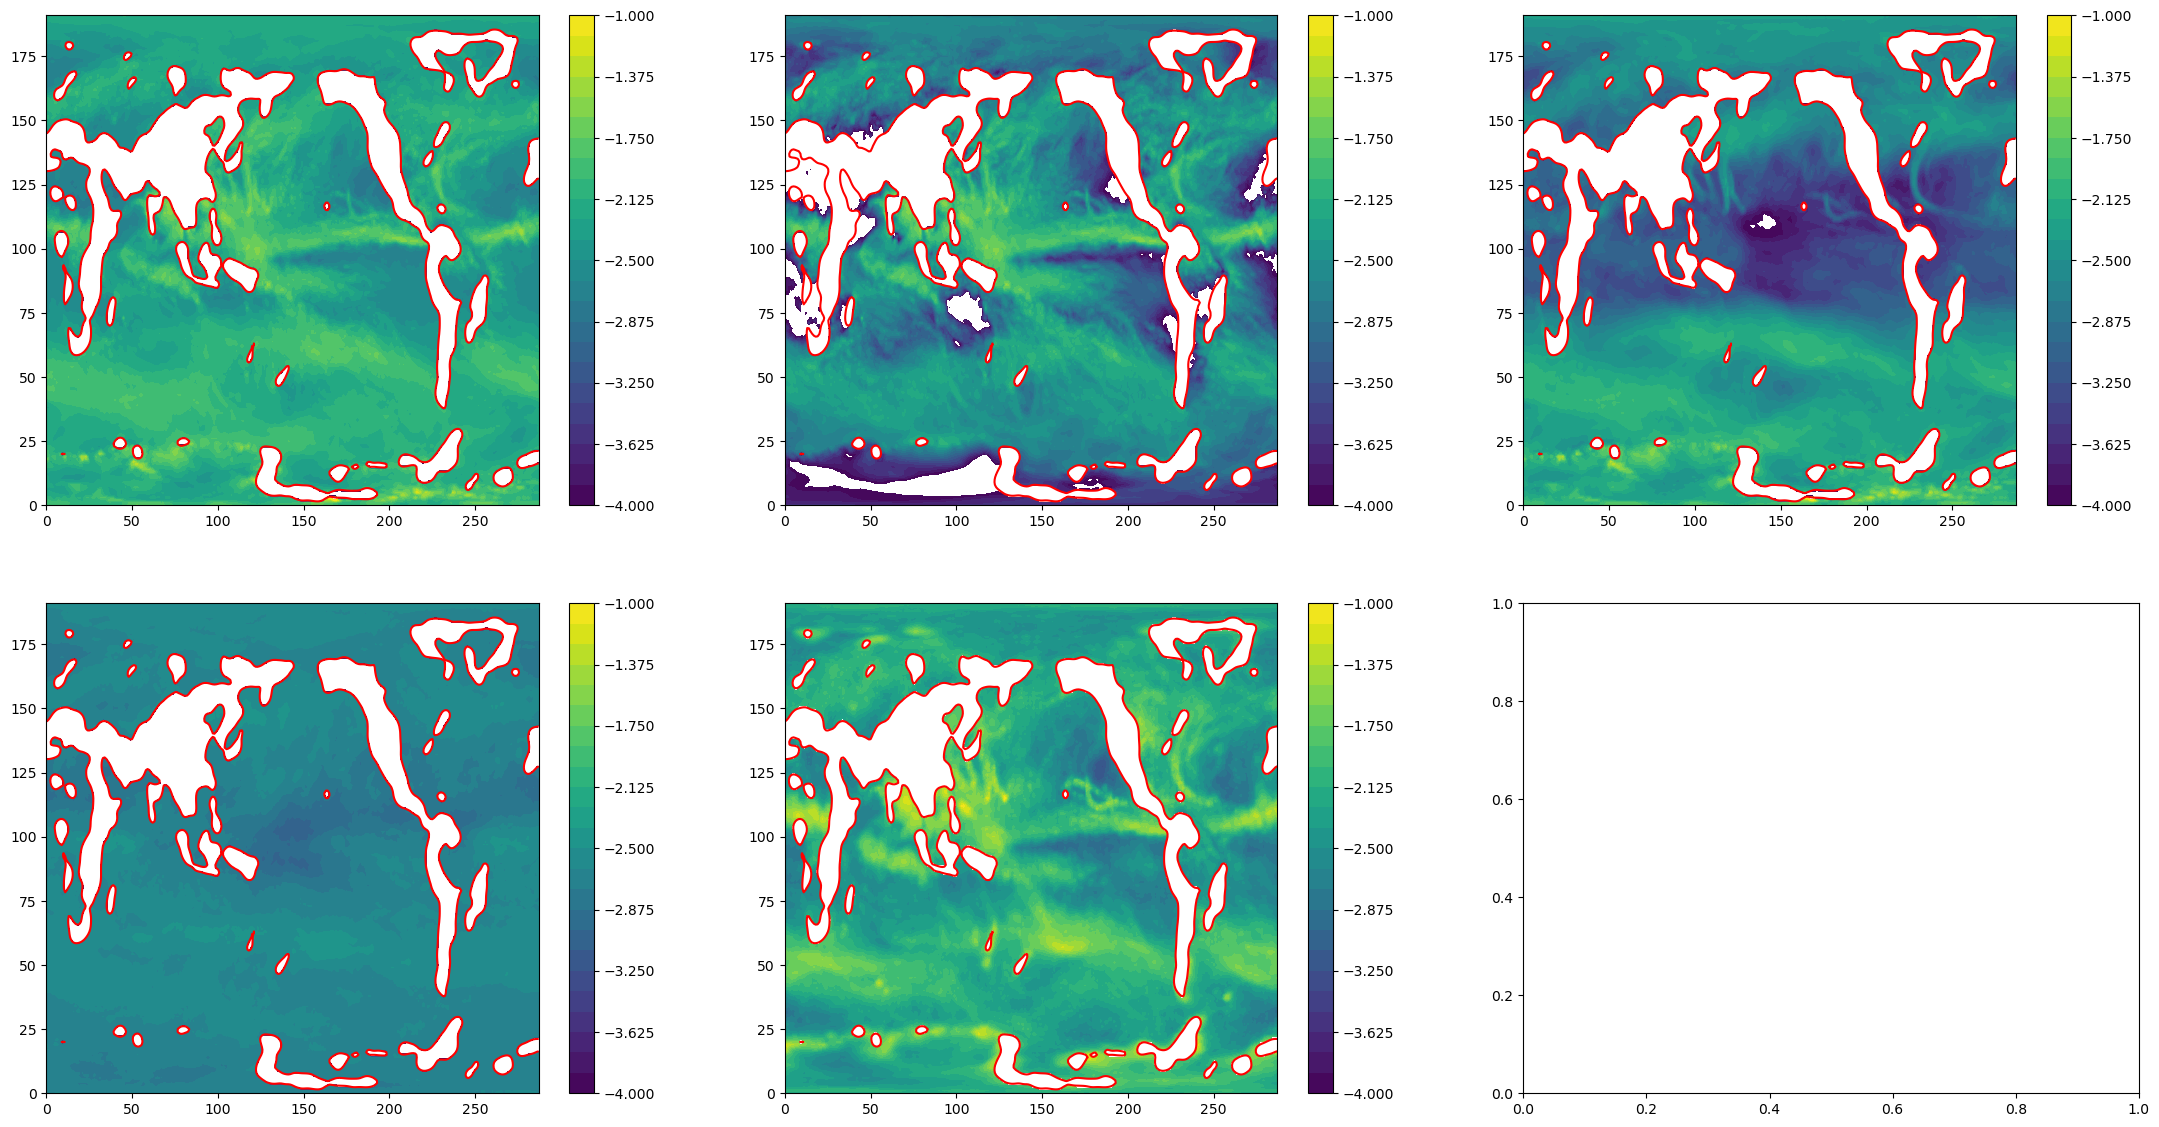

In [46]:
from scipy.ndimage import gaussian_filter

#smoothed = gaussian_filter(field, sigma=2)  # sigma in grid points

logmflv = np.linspace( -6,-1, num=25 )
logmflv = np.linspace( -4,-1, num=25 )
sgh_smooth = gaussian_filter( sgh, sigma=2) 
mxd_smooth = gaussian_filter( A.mxdis, sigma=2) 

t=100
t0,t1=0,247 #100,100
#xpwp_src_3_1.shape
fig,axs=plt.subplots( 2,3, figsize=(3*9,2*7) ) 
axs=axs.flatten()
p=0
ax=axs[p]
co=ax.contourf(  np.log10( 1*epwp_pred_3_tyx [t0:t1+1,:,:].mean( axis=0)+1e-6) , levels=logmflv )
#li=ax.contour( sgh_smooth , levels=[100,1000] , colors='black' )
lu=ax.contour( mxd_smooth , levels=[200,2000] , colors='red' )
plt.colorbar( co )
"""
p=p+1
ax=axs[p]
co=ax.contourf(  np.log10( 1*epwp_pred_4_tyx [t0:t1+1,:,:].mean( axis=0)+1e-6) , levels=logmflv )
#li=ax.contour( sgh_smooth , levels=[100,1000] , colors='black' )
lu=ax.contour( mxd_smooth , levels=[200,2000] , colors='red' )
plt.colorbar( co )
"""
p=p+1
ax=axs[p]
co=ax.contourf(  np.log10( 1*epwp_pred_5_tyx [t0:t1+1,:,:].mean( axis=0)+1e-6) , levels=logmflv )
#li=ax.contour( sgh_smooth , levels=[100,1000] , colors='black' )
lu=ax.contour( mxd_smooth , levels=[200,2000] , colors='red' )
plt.colorbar( co )
p=p+1
ax=axs[p]
co=ax.contourf(  np.log10( 1*epwp_pred_6_tyx [t0:t1+1,:,:].mean( axis=0)+1e-6) , levels=logmflv )
#li=ax.contour( sgh_smooth , levels=[100,1000] , colors='black' )
lu=ax.contour( mxd_smooth , levels=[200,2000] , colors='red' )
plt.colorbar( co )
p=p+1
ax=axs[p]
co=ax.contourf(  np.log10( 1*epwp_pred_7_tyx [t0:t1+1,:,:].mean( axis=0)+1e-6) , levels=logmflv )
#li=ax.contour( sgh_smooth , levels=[100,1000] , colors='black' )
lu=ax.contour( mxd_smooth , levels=[200,2000] , colors='red' )
plt.colorbar( co )
p=p+1
ax=axs[p]
co=ax.contourf(   np.log10( epwp_zl_mask[t0:t1+1,:,:].mean( axis=0)  ) , levels=logmflv )
#li=ax.contour( sgh_smooth , levels=[100,1000] , colors='black' )
lu=ax.contour( mxd_smooth , levels=[200, 2000] , colors='red' )
plt.colorbar( co )


Text(0, 0.5, 'pred')

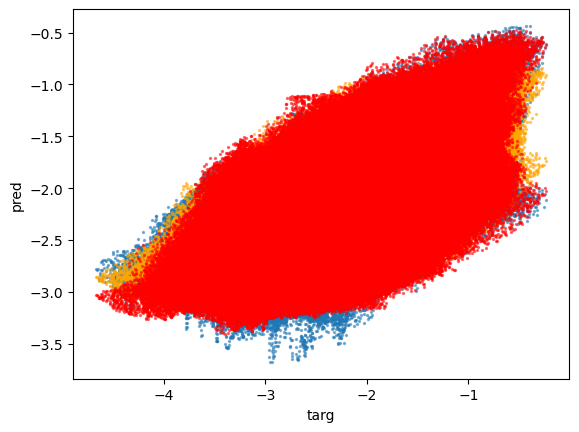

In [33]:
fig, ax = plt.subplots()

ax.scatter(np.log10(yy+1.e-12) ,
           np.log10(epwp_pred+1.e-12) ,
           s=2, alpha=0.5)
ax.scatter(np.log10(yy+1.e-12) ,
           np.log10(epwp_pred_3+1.e-12) ,
           s=2, alpha=0.5,c='orange')
ax.scatter(np.log10(yy+1.e-12) ,
           np.log10(epwp_pred_4+1.e-12) ,
           s=2, alpha=0.5,c='red')

ax.set_xlabel('targ')
ax.set_ylabel('pred')



Text(0, 0.5, 'pred')

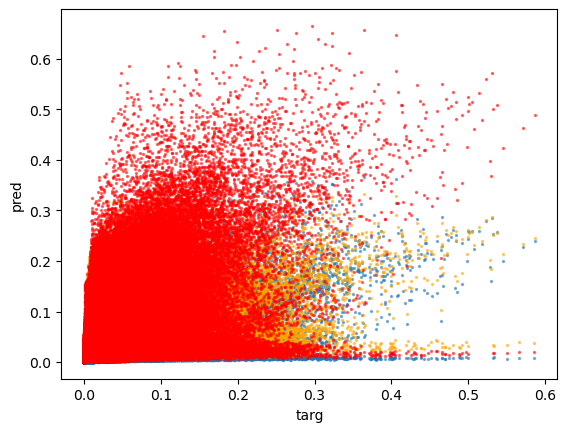

In [34]:
fig, ax = plt.subplots()

ax.scatter(yy,epwp_pred ,
           s=2, alpha=0.5)
ax.scatter(yy,2*epwp_pred_3 ,
           s=2, alpha=0.5,c='orange')
ax.scatter(yy,2*epwp_pred_4 ,
           s=2, alpha=0.5,c='red')

ax.set_xlabel('targ')
ax.set_ylabel('pred')



In [35]:
print( pa )
#epwp_pred_yx = SF.source_model( D, P, pa.y0, pa.A, pa.a, pa.D0, pa.B, pa.b, c=pa.c)
epwp_pred_yx = SF.source_model( D, P, pa.y0, pa.A, pa.a, pa.D0, pa.B, pa.b, c=pa.c)
epwp_pred_yx.shape

{'y0': np.float64(0.0), 'A': np.float64(0.08024033859682783), 'a': np.float64(1.5), 'D0': np.float64(3.000000000000001e-08), 'B': np.float64(0.0026728675895929194), 'b': np.float64(1.2), 'c': np.float64(0.1)}


(247, 192, 288)

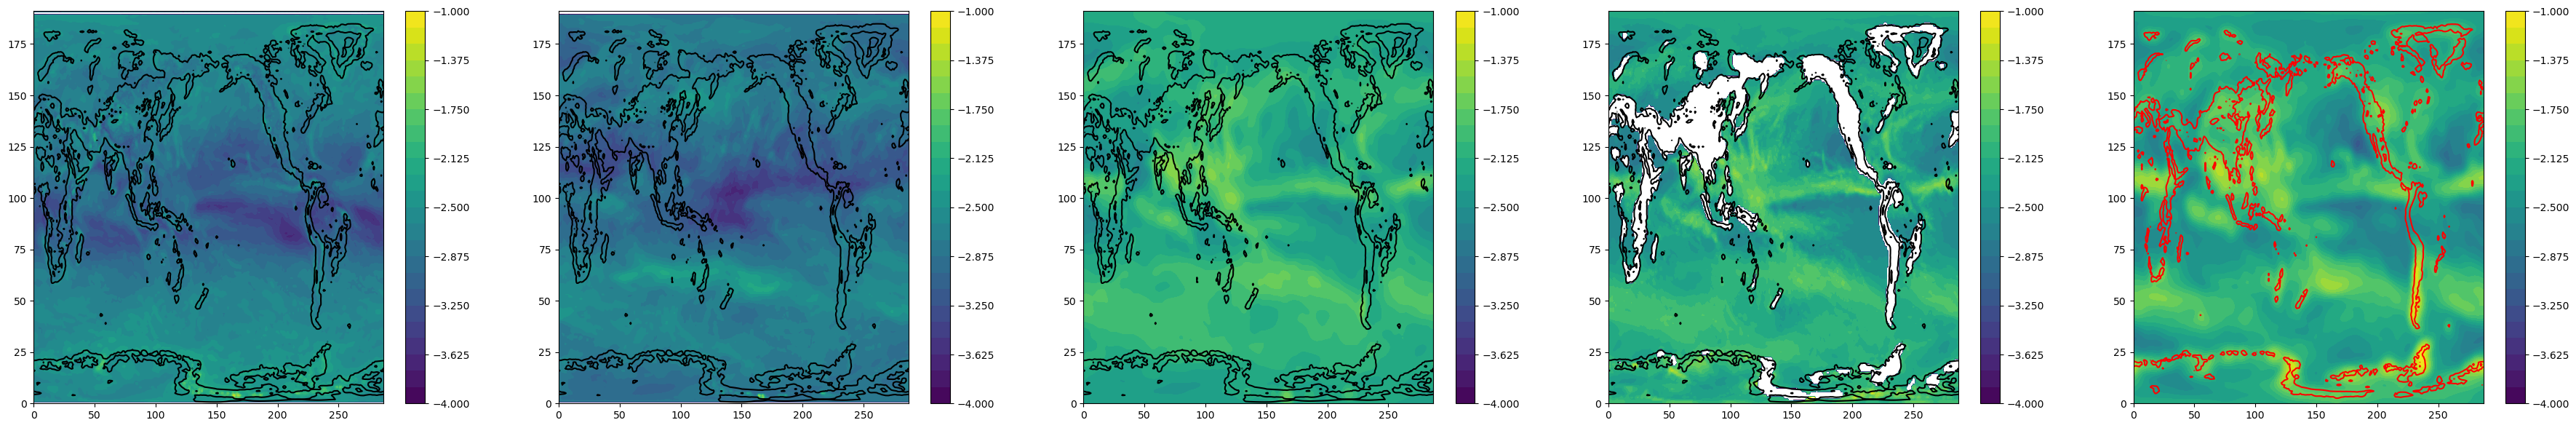

In [36]:
from scipy.ndimage import gaussian_filter

#smoothed = gaussian_filter(field, sigma=2)  # sigma in grid points

logmflv = np.linspace( -4,-1, num=25 )

sgh_smooth = gaussian_filter( sgh, sigma=0) 
#mxd_smooth = gaussian_filter( A.mxdis, sigma=1) 
t=100
t0,t1=0,247 #100,100
#xpwp_src_3_1.shape
fig,axs=plt.subplots( 1,5, figsize=(5*9,7) ) 
ax=axs[0]
co=ax.contourf(  np.log10( xpwp_src_1_2[t0:t1+1,:,:].mean( axis=0)+1e-6) , levels=logmflv )
li=ax.contour( sgh_smooth , levels=[100,1000] , colors='black' )
#lu=ax.contour( mxd_smooth , levels=[100,1000] , colors='red' )
plt.colorbar( co )
ax=axs[1]
co=ax.contourf(  np.log10( xpwp_src_3_1[t0:t1+1,:,:].mean( axis=0)+1e-6) , levels=logmflv )
li=ax.contour( sgh_smooth , levels=[100,1000] , colors='black' )
#lu=ax.contour( mxd_smooth , levels=[100,1000] , colors='red' )
plt.colorbar( co )
ax=axs[2]
co=ax.contourf(  np.log10( epwp_pred_yx[t0:t1+1,:,:].mean( axis=0)+1e-6) , levels=logmflv )
li=ax.contour( sgh_smooth , levels=[100,1000] , colors='black' )
#lu=ax.contour( mxd_smooth , levels=[100,1000] , colors='red' )
plt.colorbar( co )
ax=axs[3]
co=ax.contourf(  np.log10( epwp_pred_3_tyx[t0:t1+1,:,:].mean( axis=0)+1e-6) , levels=logmflv )
li=ax.contour( sgh_smooth , levels=[100,1000] , colors='black' )
#lu=ax.contour( mxd_smooth , levels=[100,1000] , colors='red' )
plt.colorbar( co )
ax=axs[4]
co=ax.contourf(   np.log10( Y[t0:t1+1,:,:].mean( axis=0)  ) , levels=logmflv )
#li=ax.contour( sgh_smooth , levels=[100,1000] , colors='black' )
lu=ax.contour( sgh_smooth , levels=[200, 2000] , colors='red' )
plt.colorbar( co )


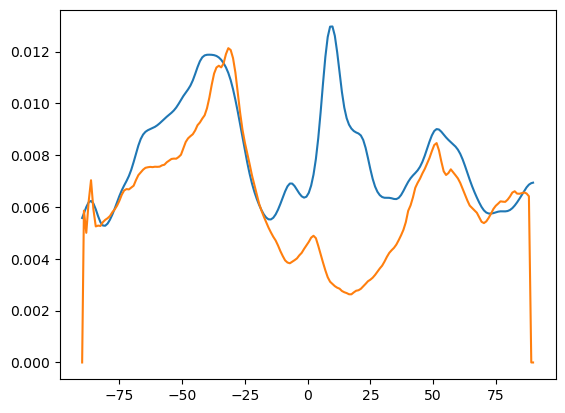

In [37]:
plt.plot( lat, np.mean( epwp_pred_yx[t0:t1+1,:,:] , axis=(0,2) ) )
#plt.plot( lat, np.mean( Y[t0:t1+1,:,:] , axis=(0,2) ) )
plt.plot( lat, np.mean( 4*xpwp_src_3_1[t0:t1+1,:,:] , axis=(0,2) ) )


In [38]:
print( poopypants )

NameError: name 'poopypants' is not defined

In [ ]:
par6 = g6['params']


s6 = SF.score(dd, pp, yy, par6, label='6-param, SH-fit ')
s6N = SF.score(ddN, ppN, yyN, par6, label='6-param, SH-fit -> NH')


In [ ]:
par7 = g7['params']


s7 = SF.score(dd, pp, yy, par7, label='7-param, SH-fit ')
s7N = SF.score(ddN, ppN, yyN, par7, label='7-param, SH-fit -> NH')


In [ ]:
v = np.nanmax(np.abs(res))
plt.pcolormesh(np.log10(pc), np.log10(dc), res, cmap='RdBu_r',
               vmin=-v, vmax=v, shading='nearest')
plt.colorbar(label='median log(pred/obs)')
plt.xlabel('log10 precl'); plt.ylabel('log10 D')

In [ ]:
sp['cell_var'].shape

In [ ]:
dc = np.sqrt(d_edges[:-1] * d_edges[1:])
pc = np.sqrt(np.maximum(p_edges[:-1], p_dry) * p_edges[1:])

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
for j in range(med.shape[1]):
    ax[0].plot(dc, med[:, j], marker='o', ms=3, lw=2 if j == 0 else 1,
               color='k' if j == 0 else None,
               label='dry' if j == 0 else f'{pc[j]:.1e}')
ax[0].set(xscale='log', yscale='log', xlabel='D', ylabel='median epwp')
ax[0].legend(fontsize=6, ncol=2)
for i in range(med.shape[0]):
    ax[1].plot(pc[1:], med[i, 1:], marker='o', ms=3)
ax[1].set(xscale='log', yscale='log', xlabel='precl', ylabel='median epwp')

In [ ]:
plt.contourf( np.log10(med) )

In [ ]:

# drop the dry column — log(P) is undefined there, and it's a
# qualitatively different class anyway. Keep it in mind separately.
Z = np.log10(med[:, 1:])
X = np.log10(pc[1:])      # log precl, bin centres
Y = np.log10(dc)          # log D, bin centres

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

im = ax[0].pcolormesh(X, Y, Z, shading='nearest', cmap='viridis')
cs = ax[0].contour(X, Y, Z, levels=12, colors='k', linewidths=0.5)
ax[0].clabel(cs, fontsize=6, fmt='%.2f')
ax[0].set(xlabel='log10 precl', ylabel='log10 D',
          title='log10 median epwp')
fig.colorbar(im, ax=ax[0])

# same surface with the dry-column baseline removed
im2 = ax[1].pcolormesh(X, Y, med[:, 1:] - med[:, [0]],
                       shading='nearest', cmap='magma')
ax[1].set(xlabel='log10 precl', ylabel='log10 D',
          title='median epwp − dry (linear)')
fig.colorbar(im2, ax=ax[1])
plt.tight_layout()

In [ ]:
print(med.shape)
from mpl_toolkits.mplot3d import Axes3D
XX, YY = np.meshgrid(X, Y)
fig = plt.figure(figsize=(7, 6))
ax3 = fig.add_subplot(111, projection='3d')
ax3.plot_surface(XX, YY, Z, cmap='viridis', edgecolor='k', lw=0.2)
ax3.set(xlabel='log10 precl', ylabel='log10 D', zlabel='log10 epwp')

In [ ]:
fig, ax = plt.subplots()

ax.scatter(dd,
           yy,
           s=5, alpha=0.5)

#ax.scatter(D[:, mask].ravel(),
#           Y[:, mask].ravel(),
#           s=5, alpha=0.5)

ax.set_xlabel('Pred')
ax.set_ylabel('epwp')

In [ ]:
#B,A = epwp_zl,tilt_zs 
#B,A = gaussian_filter( epwp_zl,2) ,gaussian_filter( tilt_zs ,2)
B = gaussian_filter( epwp_zl,sigma=(0,2,2) ,mode=('reflect','reflect','wrap')) 
A = gaussian_filter( tilt_zs,sigma=(0,2,2) ,mode=('reflect','reflect','wrap')) 
#B,A = GWP.precl.values,tilt_zl
#gaussian_filter( sgh, sigma=2)

A=np.log10( A + 1.e-16)
B=np.log10( B + 1.e-16 )

In [ ]:
fig, ax = plt.subplots()

ax.scatter(A[:, mask].ravel(),
           B[:, mask].ravel(),
           s=5, alpha=0.5)

ax.set_xlabel('A')
ax.set_ylabel('epwp')

In [ ]:
aa = A[:, mask].ravel()
bb = B[:, mask].ravel()

good = np.isfinite(aa) & np.isfinite(bb)

##ax.scatter(aa[good], bb[good], s=5, alpha=0.5)

In [ ]:
from matplotlib.colors import LogNorm



fig, ax = plt.subplots()

h = ax.hist2d(
    aa[good],
    bb[good],
    bins=50,
    norm=LogNorm()
)

fig.colorbar(h[3], ax=ax, label='Count')

ax.set_xlabel('A')
ax.set_ylabel('epwp')